In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, precision_score, recall_score, f1_score)
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import glob
import matplotlib.pyplot as plt
import re
import unicodedata

RANDOM_STATE = 5

In [2]:
files = glob.glob("data/*.csv")

day_re = "/([a-zA-Z]*)-"

def read_day_csv(f):
    df = pd.read_csv(f, encoding_errors="replace")
    df["day"] = re.search(day_re, f).group(1)
    return df

df = (
    pd.concat((read_day_csv(f) for f in files), ignore_index=True)
    .rename(columns=lambda s: s.strip())
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

df = df.drop(columns=["Destination Port", "Init_Win_bytes_forward",
            "Fwd Header Length", "Total Fwd Packets", "min_seg_size_forward",
            "SYN Flag Count", "Bwd Packet Length Mean"])

# Safely downcasts 64-bit data to 32-bit where there is no information loss
def down_cast(d):
    original_size = d.memory_usage(deep=True).sum()
    for col in d.select_dtypes("integer").columns:
        d[col] = pd.to_numeric(d[col], downcast="integer")
    for col in d.select_dtypes("float").columns:
        d[col] = pd.to_numeric(d[col], downcast="float")
    final_size = d.memory_usage(deep=True).sum()
    return d
df = down_cast(df)

def normalise(s):
    return (unicodedata.normalize("NFKD", str(s))
            .encode("ascii", "ignore")
            .decode("ascii"))
df["Label"] = df["Label"].apply(normalise)

In [3]:
def make_splits(df, train_days=("Monday", "Tuesday", "Wednesday"),
                cv_frac=0.2, random_state=0):
    # Splits train and test temporally by days
    # All training-day(s) attacks go to CV
    # Returns a dict of frames + novel-attack set
    is_train_day = df["day"].isin(list(train_days))
    train_all = df[is_train_day]
    test = df[~is_train_day]
 
    # compute novelty against the FULL training-day label set, pre-filter
    train_attacks = set(train_all["Label"]) - {"BENIGN"}
    test_attacks = set(test["Label"]) - {"BENIGN"}
    novel = test_attacks - train_attacks
 
    benign = train_all[train_all["Label"] == "BENIGN"]
    attacks = train_all[train_all["Label"] != "BENIGN"]
 
    fit, cv_benign = train_test_split(
        benign, test_size=cv_frac, random_state=random_state
    )
    cv = pd.concat([cv_benign, attacks], ignore_index=True)
 
    drop = ["Label", "day"]
    to_binary = lambda s: np.where(s == "BENIGN", 0, 1)
 
    return {
        "X_fit": fit.drop(columns=drop), # ENTIRELY BENIGN
        "X_cv": cv.drop(columns=drop),   # Contains all attacks in training days
        "X_test": test.drop(columns=drop),
        "y_cv": to_binary(cv["Label"]),
        "y_test": to_binary(test["Label"]),
        "cv_names": cv["Label"].to_numpy(),
        "test_names": test["Label"].to_numpy(),
        "novel": novel,
        "seen": train_attacks,
    }

In [4]:
def evaluate(preds, y, target_names, title=""):
    print(f"--- {title} ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=target_names))

def to_attack_indicator(iforest_preds):
    # iForest predict(): -1 is anomaly, 1 is benign
    # translating to 1 as anomaly, 0 as benign
    return (iforest_preds == -1).astype(int)

In [5]:
s = make_splits(df)

# Isolation Forest
First we have to remove anomalous examples from the training set. Otherwise the iForest will learn anomalous behaviour as normal! We also no longer require a cross validation set, allowing a doubling in the test set.

In [6]:
# Contamination sweep
contaminations = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]
precisions, recalls = [], []
for c in contaminations:
    clf = IsolationForest(contamination=c, random_state=RANDOM_STATE)
    clf.fit(s["X_fit"])
    val_pred = to_attack_indicator(clf.predict(s["X_cv"]))
    # precision/recall for the ATTACK class (pos_label=1)
    precisions.append(precision_score(s["y_cv"], val_pred, pos_label=1, zero_division=0))
    recalls.append(recall_score(s["y_cv"], val_pred, pos_label=1, zero_division=0))

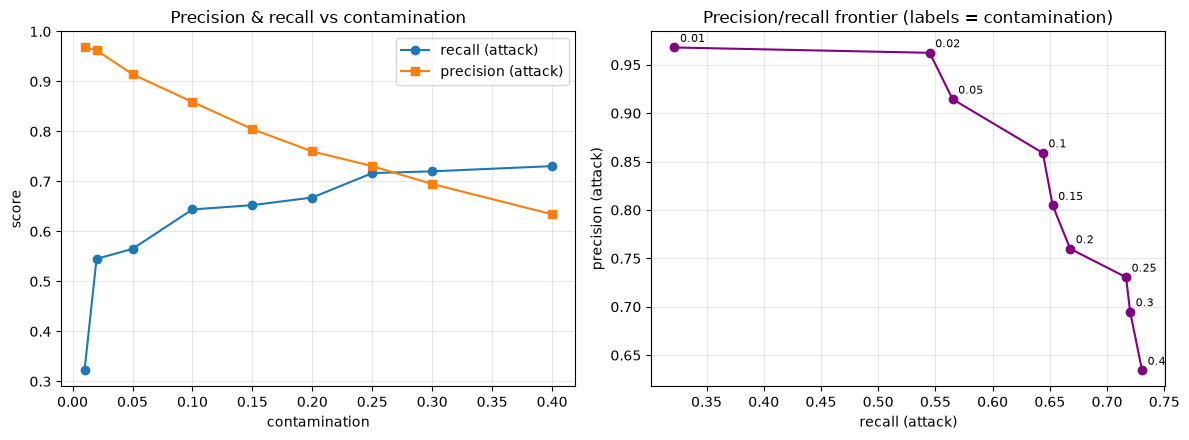

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
 
# (1) both metrics against the knob
ax1.plot(contaminations, recalls, marker="o", label="recall (attack)")
ax1.plot(contaminations, precisions, marker="s", label="precision (attack)")
ax1.set_xlabel("contamination")
ax1.set_ylabel("score")
ax1.set_title("Precision & recall vs contamination")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(recalls, precisions, marker="o", color="purple")
for c, r, p in zip(contaminations, recalls, precisions):
    ax2.annotate(f"{c}", (r, p), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax2.set_xlabel("recall (attack)")
ax2.set_ylabel("precision (attack)")
ax2.set_title("Precision/recall frontier (labels = contamination)")
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

In [8]:
target_precision_floor = 0.40
# precisions list isn't just attack precisions, but total average
viable = [(c, r, p) for c, r, p in zip(contaminations, recalls, precisions)
         if p >= target_precision_floor]
chosen_contamination = max(viable, key=lambda t: t[1])[0] if viable \
    else contaminations[int(np.argmax(recalls))]
print(f"Chosen contamination (from validation): {chosen_contamination}")

Chosen contamination (from validation): 0.4


In [9]:
final_clf = IsolationForest(contamination=chosen_contamination,
                            random_state=RANDOM_STATE, n_jobs=-1)
final_clf.fit(s["X_fit"])                
test_pred = to_attack_indicator(final_clf.predict(s["X_test"]))
 
from sklearn.metrics import classification_report
# y_test_binary: 1 = attack, 0 = benign  (make sure this matches test_pred's convention)
print(classification_report(s["y_test"], test_pred,
                            target_names=["benign", "attack"], zero_division=0))
 
# per-attack-type recall on the test days
import pandas as pd
res = pd.DataFrame({"attack": s["test_names"], "caught": test_pred})
per_type = (res[res["attack"] != "BENIGN"]
            .groupby("attack")["caught"].agg(recall="mean", n="size")
            .sort_values("recall"))
print(per_type)

              precision    recall  f1-score   support

      benign       0.78      0.63      0.69    870343
      attack       0.29      0.46      0.36    291001

    accuracy                           0.58   1161344
   macro avg       0.53      0.54      0.52   1161344
weighted avg       0.65      0.58      0.61   1161344

                             recall       n
attack                                     
PortScan                   0.122258  158804
Bot                        0.291411    1956
Web Attack  Sql Injection  0.571429      21
DDoS                       0.867799  128025
Web Attack  Brute Force    0.913072    1507
Web Attack  XSS            0.967791     652
Infiltration               0.972222      36


In [10]:
if_cv_pred = to_attack_indicator(final_clf.predict(s["X_cv"]))
res = pd.DataFrame({"attack": s["cv_names"], "caught": if_cv_pred})
per_type_cv = (res[res["attack"] != "BENIGN"]
            .groupby("attack")["caught"].agg(recall="mean", n="size")
            .sort_values("recall"))
print(per_type_cv)

                    recall       n
attack                            
SSH-Patator       0.508564    5897
FTP-Patator       0.520101    7935
DoS Hulk          0.721359  230124
DoS slowloris     0.900966    5796
DoS GoldenEye     0.986010   10293
DoS Slowhttptest  0.999454    5499
Heartbleed        1.000000      11


# Local outlier factor
Unlike iForest, LOF does need to be scaled! I will use the Robust Scaler rather than a Standard Scaler. Robust uses median rather than mean, and inter quartile range rather than standard deviation. This allows it to be less skewed by extreme values, something common in the dataset by design of being normal and anomalous data.
Due to LOFs complexity, I will take a sub-sample of the benign training set of a maximum of 100,000 examples.

In [11]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler().fit(s["X_fit"])
X_fit_scaled  = pd.DataFrame(scaler.transform(s["X_fit"]),  columns = s["X_fit"].columns).drop_duplicates()
X_cv_scaled   = pd.DataFrame(scaler.transform(s["X_cv"]),   columns = s["X_cv"].columns)
X_test_scaled = pd.DataFrame(scaler.transform(s["X_test"]), columns = s["X_test"].columns) 

In [12]:
rng = np.random.default_rng(RANDOM_STATE)
n_sub = 200_000                      # tune down if still slow / memory-heavy
if len(X_fit_scaled) > n_sub:
    idx = rng.choice(len(X_fit_scaled), size=n_sub, replace=False)
    X_train_sub = X_fit_scaled.iloc[idx] if hasattr(X_fit_scaled, "iloc") \
                  else X_fit_scaled[idx]
else:
    X_train_sub = X_fit_scaled

In [13]:
# Contamination sweep
contaminations = [0.01, 0.1, 0.2, 0.4]
precisions, recalls = [], []
for c in contaminations:
    clf = LocalOutlierFactor(contamination=c, novelty=True, n_jobs=-1)
    clf.fit(X_train_sub)
    val_pred = to_attack_indicator(clf.predict(X_cv_scaled))
    # precision/recall for the ATTACK class (pos_label=1)
    precisions.append(precision_score(s["y_cv"], val_pred, pos_label=1, zero_division=0))
    recalls.append(recall_score(s["y_cv"], val_pred, pos_label=1, zero_division=0))

/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


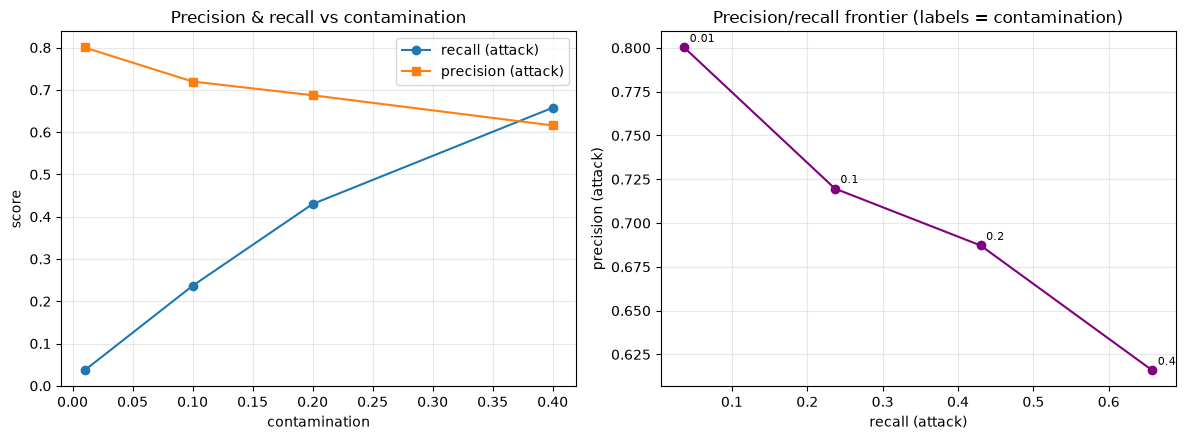

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
 
# (1) both metrics against the knob
ax1.plot(contaminations, recalls, marker="o", label="recall (attack)")
ax1.plot(contaminations, precisions, marker="s", label="precision (attack)")
ax1.set_xlabel("contamination")
ax1.set_ylabel("score")
ax1.set_title("Precision & recall vs contamination")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(recalls, precisions, marker="o", color="purple")
for c, r, p in zip(contaminations, recalls, precisions):
    ax2.annotate(f"{c}", (r, p), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax2.set_xlabel("recall (attack)")
ax2.set_ylabel("precision (attack)")
ax2.set_title("Precision/recall frontier (labels = contamination)")
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

In [15]:
target_precision_floor = 0.40
# precisions list isn't just attack precisions, but total average
viable = [(c, r, p) for c, r, p in zip(contaminations, recalls, precisions)
          if p >= target_precision_floor]
chosen_contamination = max(viable, key=lambda t: t[1])[0] if viable \
    else contaminations[int(np.argmax(recalls))]
print(f"Chosen contamination (from validation): {chosen_contamination}")

Chosen contamination (from validation): 0.4


In [16]:
neighbor_grid = [10, 20, 35, 50]
best = None
for k in neighbor_grid:
    lof = LocalOutlierFactor(n_neighbors=k, contamination=chosen_contamination,
                             novelty=True, n_jobs=-1)
    lof.fit(X_train_sub)
    val_pred = to_attack_indicator(lof.predict(X_cv_scaled)) 
    r = recall_score(s["y_cv"], val_pred, pos_label=1, zero_division=0)
    p = precision_score(s["y_cv"], val_pred, pos_label=1, zero_division=0)
    print(f"n_neighbors={k}: recall={r:.3f} precision={p:.3f}")
    # Choosing number of neighbours entirely based on recall
    # Possibly would be better to grade on F1 (or F2 as I care so much about recall)?
    if best is None or r > best[1]:
        best = (k, r, p)
 
best_k = best[0]
print(f"Chosen n_neighbors (validation): {best_k}")

/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


n_neighbors=10: recall=0.675 precision=0.613


/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


n_neighbors=20: recall=0.658 precision=0.616


/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


n_neighbors=35: recall=0.603 precision=0.593


/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


n_neighbors=50: recall=0.481 precision=0.538
Chosen n_neighbors (validation): 10


In [17]:
lof_final = LocalOutlierFactor(n_neighbors=best_k, contamination=chosen_contamination,
                               novelty=True, n_jobs=-1)
lof_final.fit(X_train_sub)

lof_pred = to_attack_indicator(lof_final.predict(X_cv_scaled))
res = pd.DataFrame({"attack": s["cv_names"], "caught": lof_pred})
per_type_lof = (res[res["attack"] != "BENIGN"]
                .groupby("attack")["caught"].agg(recall="mean", n="size")
                .sort_values("recall"))
print(per_type_lof)


lof_pred = to_attack_indicator(lof_final.predict(X_test_scaled))
 
print(classification_report(s["y_test"], lof_pred,
                            target_names=["benign", "attack"], zero_division=0))
 
res = pd.DataFrame({"attack": s["test_names"], "caught": lof_pred})
per_type_lof = (res[res["attack"] != "BENIGN"]
                .groupby("attack")["caught"].agg(recall="mean", n="size")
                .sort_values("recall"))
print(per_type_lof)

/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


                    recall       n
attack                            
SSH-Patator       0.269459    5897
DoS Slowhttptest  0.429896    5499
FTP-Patator       0.550095    7935
DoS GoldenEye     0.675799   10293
DoS Hulk          0.691518  230124
DoS slowloris     0.824189    5796
Heartbleed        1.000000      11


/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

      benign       0.95      0.54      0.69    870343
      attack       0.40      0.91      0.55    291001

    accuracy                           0.63   1161344
   macro avg       0.67      0.72      0.62   1161344
weighted avg       0.81      0.63      0.65   1161344

                             recall       n
attack                                     
Web Attack  Sql Injection  0.428571      21
Bot                        0.472393    1956
Infiltration               0.805556      36
DDoS                       0.814575  128025
Web Attack  Brute Force    0.880557    1507
Web Attack  XSS            0.957055     652
PortScan                   0.992828  158804


# Cascade synthesis

In [18]:
comparison = per_type.rename(columns={"recall": "iForest"}).join(
    per_type_lof.rename(columns={"recall": "LOF"})["LOF"]
)
print(comparison[["iForest", "LOF", "n"]])

                            iForest       LOF       n
attack                                               
PortScan                   0.122258  0.992828  158804
Bot                        0.291411  0.472393    1956
Web Attack  Sql Injection  0.571429  0.428571      21
DDoS                       0.867799  0.814575  128025
Web Attack  Brute Force    0.913072  0.880557    1507
Web Attack  XSS            0.967791  0.957055     652
Infiltration               0.972222  0.805556      36


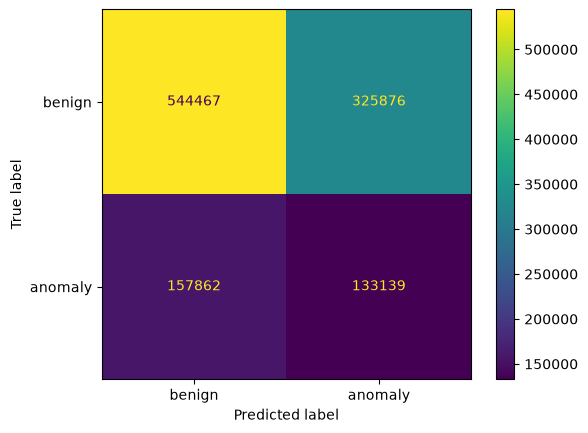

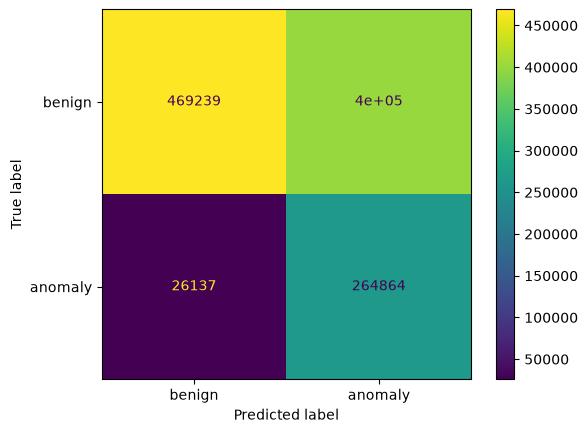

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
if_cm = confusion_matrix(s["y_test"], test_pred, labels=[0, 1])
ConfusionMatrixDisplay(if_cm, display_labels=["benign", "anomaly"]).plot()
lof_cm = confusion_matrix(s["y_test"], lof_pred, labels=[0,1])
ConfusionMatrixDisplay(lof_cm, display_labels=["benign", "anomaly"]).plot()

## iForest OR LOF

FPR: 0.6509215332345983
              precision    recall  f1-score   support

      benign       0.99      0.35      0.52    870343
      attack       0.34      0.99      0.50    291001

    accuracy                           0.51   1161344
   macro avg       0.66      0.67      0.51   1161344
weighted avg       0.82      0.51      0.51   1161344

                             recall       n
attack                                     
Bot                        0.681493    1956
Web Attack  Sql Injection  0.714286      21
Web Attack  Brute Force    0.937624    1507
Infiltration               0.972222      36
Web Attack  XSS            0.973926     652
DDoS                       0.976911  128025
PortScan                   0.999975  158804


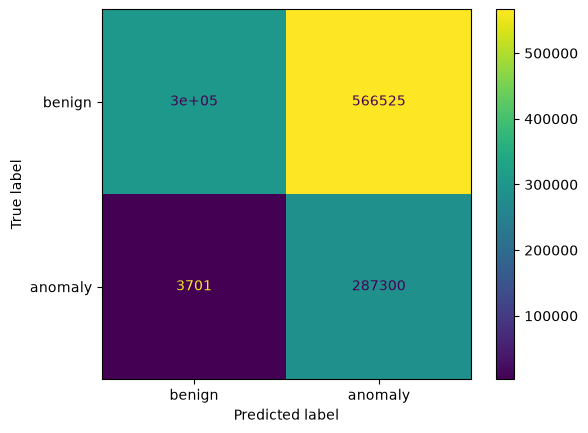

In [20]:
or_preds = lof_pred | test_pred

or_cm = confusion_matrix(s["y_test"], or_preds, labels=[0, 1])
or_fpr = or_cm[0][1] / (or_cm[0][1] + or_cm[0][0])
print(f"FPR: {or_fpr}")
ConfusionMatrixDisplay(or_cm, display_labels=["benign", "anomaly"]).plot()

print(classification_report(s["y_test"], or_preds,
                            target_names=["benign", "attack"], zero_division=0))

res = pd.DataFrame({"attack": s["test_names"], "caught": or_preds})
per_type_or = (res[res["attack"] != "BENIGN"]
                .groupby("attack")["caught"].agg(recall="mean", n="size")
                .sort_values("recall"))
print(per_type_or)

## iForest AND LOF

FPR: 0.18435835067324033
              precision    recall  f1-score   support

      benign       0.80      0.82      0.81    870343
      attack       0.41      0.38      0.39    291001

    accuracy                           0.71   1161344
   macro avg       0.60      0.60      0.60   1161344
weighted avg       0.70      0.71      0.70   1161344

                             recall       n
attack                                     
Bot                        0.082311    1956
PortScan                   0.115110  158804
Web Attack  Sql Injection  0.285714      21
DDoS                       0.705464  128025
Infiltration               0.805556      36
Web Attack  Brute Force    0.856005    1507
Web Attack  XSS            0.950920     652


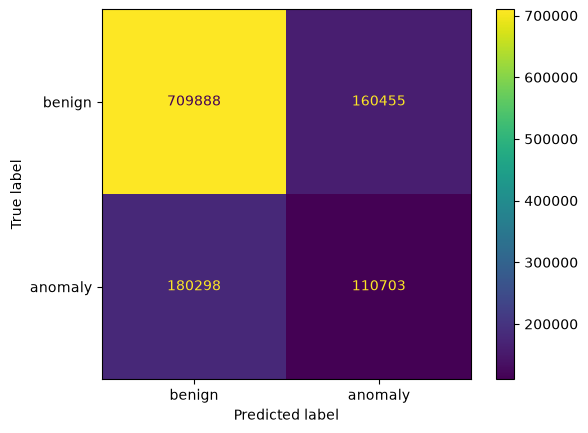

In [21]:
and_preds = lof_pred & test_pred

and_cm = confusion_matrix(s["y_test"], and_preds, labels=[0, 1])
and_fpr = and_cm[0][1] / (and_cm[0][1] + and_cm[0][0])
print(f"FPR: {and_fpr}")
ConfusionMatrixDisplay(and_cm, display_labels=["benign", "anomaly"]).plot()

print(classification_report(s["y_test"], and_preds,
                            target_names=["benign", "attack"], zero_division=0))

res = pd.DataFrame({"attack": s["test_names"], "caught": and_preds})
per_type_and = (res[res["attack"] != "BENIGN"]
                .groupby("attack")["caught"].agg(recall="mean", n="size")
                .sort_values("recall"))
print(per_type_and)

## Score-combination
Use decision_function and score_samples to get array of "anomaly scores". Higher = more anomalous. 

These anomaly scores have to be scaled so the later combination actually makes sense and isn't just dominated by the one that scaled to a range with larger numbers.

After z-scoring, the score itself tells us how many standard deviations above the mean anomaly-score the point is. 0 = average-scoring flow, negative is less anomalous, positive is more anomalous. 

In [18]:
# iForest: decision_function -> higher = more benign. 
# LOF: score_samples -> higher = more benign.
# After negation, higher = more anomalous

if_score_cv  = -final_clf.decision_function(s["X_cv"])
lof_score_cv = lof_final.score_samples(X_cv_scaled)

if_score_test  = -final_clf.decision_function(s["X_test"])
lof_score_test = lof_final.score_samples(X_test_scaled)

/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/home/village-spearman/Documents/ML-IDS/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [ ]:
# Both have different scales, so need to be normalised
def zscore_fitter(a):
    mu, sd = a.mean(), a.std()
    return mu, (sd if sd > 0 else 1.0)

if_mu, if_sd = zscore_fitter(if_score_cv)
lof_mu, lof_sd = zscore_fitter(-lof_score_cv)

z = lambda a, mu, sd: (a - mu) / sd
if_cv  = z(if_score_cv, if_mu, if_sd)
lof_cv = z(-lof_score_cv, lof_mu, lof_sd)
# Test scaled on mean and standard deviation from cross validation
if_test  = z(if_score_test, if_mu, if_sd)
lof_test = z(-lof_score_test, lof_mu, lof_sd)

In [ ]:
inspect = pd.DataFrame({
    "attack": s["test_names"],
    "if": if_test,
    "lof":  lof_test,
})

print(inspect.groupby("attack")[["if", "lof"]].median().sort_values("lof"))

print(inspect.groupby("attack")[["if", "lof"]].mean().sort_values("lof"))

In [ ]:
np.percentile(if_test, [1,50,99])

In [ ]:
np.percentile(lof_test, [1,50,99])

LOF scores are a little flat. 
Perhaps Robust will give a more comparable scale?

In [ ]:
def robust_fitter(a):
    med = np.median(a)
    q75, q25 = np.percentile(a, [75, 25])
    iqr = (q75-q25) or 1.0
    return med, iqr

if_med, if_iqr = robust_fitter(if_score_cv)
lof_med, lof_iqr = robust_fitter(lof_score_cv)

rob = lambda a, med, iqr: (a - med) / iqr
if_test  = rob(if_score_test, if_med, if_iqr)
lof_test = rob(lof_score_test, lof_med, lof_iqr)

In [ ]:
inspect = pd.DataFrame({
    "attack": s["test_names"],
    "if": if_test,
    "lof":  lof_test,
})

print(inspect.groupby("attack")[["if", "lof"]].median().sort_values("lof"))

print(inspect.groupby("attack")[["if", "lof"]].mean().sort_values("lof"))

In [ ]:
np.percentile(if_test, [1,50,99])

In [ ]:
np.percentile(lof_test, [1,50,99])

Even after robust scaling the scores aren't on the same scale. 
Perhaps using rank transform. Score each value to it's percentile rank [0,1] within the set. Outliers won't dominate and LOF and iForest will have identical ranges for later combination.

In [19]:
from scipy.stats import rankdata
def to_rank(a):
    """Percentile rank in [0,1]. Ranking has no fitted params, so applying it
    per-set doesn't leak label info — each set is ranked within itself."""
    return rankdata(a, method="average") / len(a)
 
if_r_cv,  lof_r_cv  = to_rank(if_score_cv),   to_rank(-lof_score_cv)
if_r_test, lof_r_test = to_rank(if_score_test), to_rank(-lof_score_test)

In [20]:
print("iForest rank range:", if_r_test.min(), if_r_test.max())
print("LOF rank range:    ", lof_r_test.min(),  lof_r_test.max())  

iForest rank range: 6.458034828612366e-06 1.0
LOF rank range:     8.610713104816489e-07 1.0


In [21]:
inspect = pd.DataFrame({
    "attack": s["test_names"],
    "if_rank": if_r_test,
    "lof_rank":  lof_r_test,
})
print(inspect.groupby("attack")[["if_rank", "lof_rank"]].median().sort_values("lof_rank"))

                            if_rank  lof_rank
attack                                       
Web Attack  Sql Injection  0.706120  0.326308
Bot                        0.579338  0.377257
BENIGN                     0.436889  0.394555
Infiltration               0.970740  0.671090
PortScan                   0.494585  0.781499
DDoS                       0.888253  0.814408
Web Attack  XSS            0.682346  0.976967
Web Attack  Brute Force    0.682346  0.977083


In [22]:
def fpr_recall(scores, thr, y):
    pred = (scores >= thr).astype(int)
    tp = ((pred==1)&(y==1)).sum(); fn = ((pred==0)&(y==1)).sum()
    fp = ((pred==1)&(y==0)).sum(); tn = ((pred==0)&(y==0)).sum()
    return (tp/(tp+fn) if tp+fn else 0), (fp/(fp+tn) if fp+tn else 0)

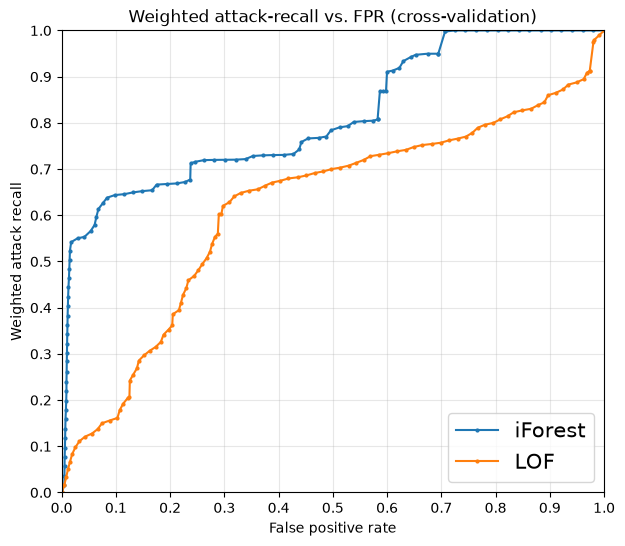

In [30]:
plt.figure(figsize=(7,6))
plt.xlim(0, 1)
plt.ylim(0, 1)
from matplotlib.ticker import MultipleLocator
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))

thresholds = np.linspace(0, 1, 100)
# for name, combined in combiners_cv.items():
rs, fs = zip(*[fpr_recall(if_r_cv, t, s["y_cv"]) for t in thresholds])
plt.plot(fs, rs, marker=".", markersize=4, label="iForest")

rs, fs = zip(*[fpr_recall(lof_r_cv, t, s["y_cv"]) for t in thresholds])
plt.plot(fs, rs, marker=".", markersize=4, label="LOF")

# plt.scatter(or_fpr, 1.00, color="red",    zorder=5, label="OR")
# plt.scatter(and_fpr, 0.37, color="orange", zorder=5, label="AND")
 
plt.xlabel("False positive rate"); plt.ylabel("Weighted attack recall")
plt.title("Weighted attack-recall vs. FPR (cross-validation)")
plt.legend(prop={'size': 15}, loc=4); plt.grid(alpha=0.3); plt.show()

In [ ]:
# combined = combiners_cv["if-biased"]
# results = [(t, *fpr_recall(combined, t, s["y_cv"])) for t in thresholds]
# # each row: (threshold, recall, fpr)
# viable = [(t, r, f) for (t, r, f) in results if f <= 0.05]
# best = max(viable, key=lambda x: x[1])   # highest recall under the FPR cap
# print(f"threshold={best[0]:.3f}, recall={best[1]:.3f}, fpr={best[2]:.3f}")

The obvious choice from the above is mean with the threshold achieving recall around 0.60 and FPR around 0.05.
Beyond this FPR, for mean there is no real gain in attack recall. The other models have far too great an FPR to match the recall of mean.

In [25]:

CHOSEN = "LOF"                     # set from the frontier
CHOSEN_THR = 0.7               # set from validation sweep
 
combined_tests = {
    # "max":  np.maximum(if_r_test, lof_r_test),
    # "mean": (if_r_test + lof_r_test) / 2,
    # "min":  np.minimum(if_r_test, lof_r_test),
    # "lof-biased": (if_r_test + 3*lof_r_test) / 4,
    # "if-biased": (3*if_r_test + lof_r_test) / 4,
    "iForest": if_r_test,
    "LOF": lof_r_test,
}
combined_test = combined_tests[CHOSEN]
 
final_pred = (combined_test >= CHOSEN_THR).astype(int)
print(classification_report(s["y_test"], final_pred,
                            target_names=["benign","attack"], zero_division=0))
 
res = pd.DataFrame({"attack": s["test_names"], "caught": final_pred})
per_type = (res[res["attack"]!="BENIGN"]
            .groupby("attack")["caught"].agg(recall="mean", n="size")
            .sort_values("recall"))
print(per_type)

cm = confusion_matrix(s["y_test"], final_pred, labels=[0, 1])
fpr = cm[0][1] / (cm[0][1] + cm[0][0])
print(f"FPR: {fpr}")
ConfusionMatrixDisplay(cm, display_labels=["benign", "anomaly"]).plot()

              precision    recall  f1-score   support

      benign       0.90      0.84      0.87    870343
      attack       0.60      0.72      0.66    291001

    accuracy                           0.81   1161344
   macro avg       0.75      0.78      0.76   1161344
weighted avg       0.83      0.81      0.82   1161344

                             recall       n
attack                                     
Bot                        0.125256    1956
Web Attack  Sql Injection  0.190476      21
Infiltration               0.416667      36
DDoS                       0.584886  128025
Web Attack  Brute Force    0.810883    1507
PortScan                   0.837668  158804
Web Attack  XSS            0.935583     652


NameError: name 'confusion_matrix' is not defined

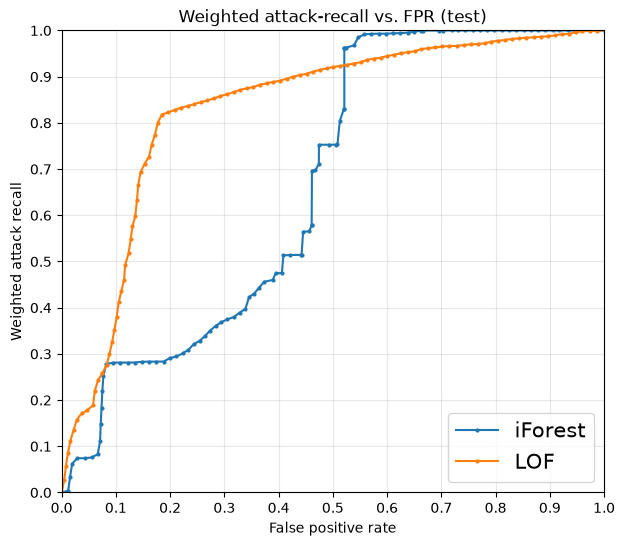

In [31]:
plt.figure(figsize=(7,6))
plt.xlim(0, 1)
plt.ylim(0, 1)
from matplotlib.ticker import MultipleLocator
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))

thresholds = np.linspace(0, 1, 100)
for name, combined in combined_tests.items():
    rs, fs = zip(*[fpr_recall(combined, t, s["y_test"]) for t in thresholds])
    plt.plot(fs, rs, marker=".", markersize=4, label=name)

# rs, fs = zip(*[fpr_recall(lof_r_test, t, s["y_test"]) for t in thresholds])
# plt.plot(fs, rs, marker=".", markersize=2, label="lof")
    
# plt.scatter(or_fpr, 1.00, color="red",    zorder=5, label="OR")
# plt.scatter(and_fpr, 0.37, color="orange", zorder=5, label="AND")
 
plt.xlabel("False positive rate"); plt.ylabel("Weighted attack recall")
plt.title("Weighted attack-recall vs. FPR (test)")
plt.legend(prop={'size': 15}, loc=4); plt.grid(alpha=0.3); plt.show()